In [1]:
import polars as pl
import numpy as np
import seaborn as sns
from pathlib import Path
from tem import model
design_dir = Path("~/VSCode/operators/design").expanduser()
n_subj = 30

In [2]:
n_runs = 100

# study_dir = sim_dir / "assoc-1"
# while study_dir.exists():
#     number = int(study_dir.name.split("-")[1])
#     study_dir = sim_dir / f"assoc-{number + 1}"
# study_dir.mkdir()

rng = np.random.default_rng(1)
par = [1, 1, 5]
L = 0.5

df_list = []
for number in range(1, n_subj + 1):
    subject = f"{number:03d}"
    if number % 2 == 0:
        condition = "AL"
    else:
        condition = "PI"

    raw_file = design_dir / f"sub-{subject}" / f"sub-{subject}_task-learning_design.csv"
    raw = pl.read_csv(raw_file)
    trials = raw.filter(
        ~(
            pl.col("trial_type").str.starts_with("practice")
            | pl.col("trial_type").str.contains("instruction")
            | pl.col("trial_type").str.contains("feedback")
        )
    )

    graph1 = trials.filter(graph="graph_1")
    graph2 = trials.filter(graph="graph_2")

    for run in range(1, n_runs + 1):
        correct1, _ = model.simulate_strength(graph1, rng, L, *par)
        correct2, _ = model.simulate_strength(graph2, rng, L, *par)

        graph1 = graph1.with_columns(
            subject=pl.lit(subject),
            condition=pl.lit(condition),
            graph=pl.lit("initial"),
            run=run,
            correct=correct1,
        )
        graph2 = graph2.with_columns(
            subject=pl.lit(subject),
            condition=pl.lit(condition),
            graph=pl.lit("transfer"),
            run=run,
            correct=correct2,
        )

        df_list.append(graph1)
        df_list.append(graph2)
df = pl.concat(df_list)

In [3]:
df = df.with_columns(
    smooth_value=pl.col("correct").rolling_mean(window_size=50).over("subject", "run", "graph", "block"),
    trial=pl.col("trial_number").cum_count().over("subject", "run"),
)

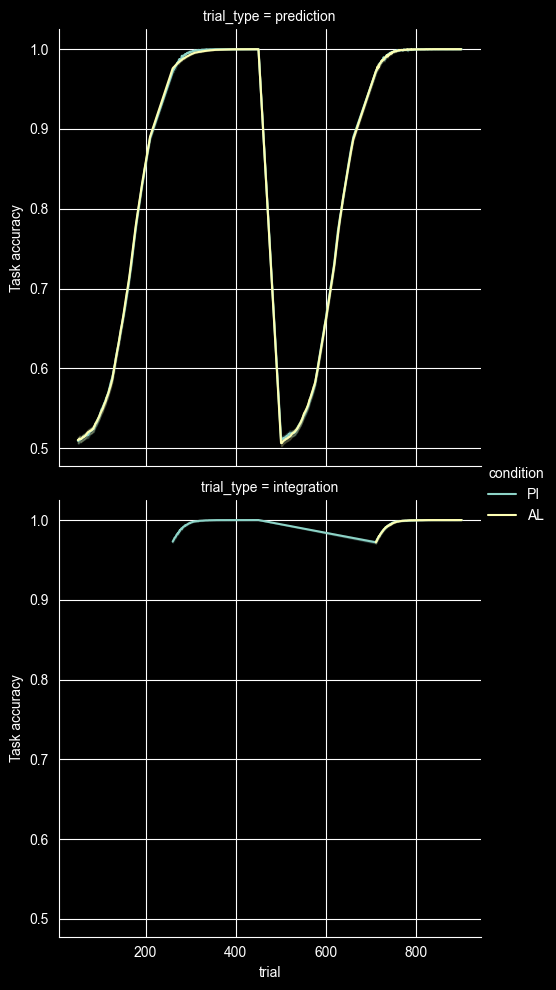

In [4]:
g = sns.relplot(
    df,
    x="trial",
    y="smooth_value",
    kind="line",
    hue="condition",
    row="trial_type",
)
g.set(ylabel="Task accuracy")